## Recitation 3

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots  # noqa

from scipy.integrate import solve_ivp
from matplotlib.animation import FuncAnimation

%matplotlib inline

### Problem 2

In [ ]:
plt.style.use(["science", "grid", "ieee"])
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6, 8), dpi=96)

ax1.set_xlim(0, 4 * np.pi)
ax1.set_ylim(-1, 1)
ax2.set_xlim(0, 3)
ax2.set_ylim(-1, 1)
ax3.set_xlim(0, 4 * np.pi)
ax3.set_ylim(-1, 1)

(line1,) = ax1.plot([], [], label="$u_1$")
(line2,) = ax1.plot([], [], label="$u_1'$")
(line3,) = ax2.plot([], [], "o")
(line4,) = ax3.plot([], [], label="$u_2$")
(line5,) = ax3.plot([], [], label="$u_2'$")

ax1.set_xlabel("t")
ax1.set_ylabel("value")
ax1.legend()
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax3.set_xlabel("t")
ax3.set_ylabel("value")
ax3.legend()


# update function
def update(t):
    x = np.arange(0, t, 0.01)
    y1 = 0.5 * np.sin(x) - np.sqrt(3) / 6 * np.sin(np.sqrt(3) * x)
    y11 = 0.5 * np.cos(x) - 0.5 * np.cos(np.sqrt(3) * x)
    y2 = 0.5 * np.sin(x) + np.sqrt(3) / 6 * np.sin(np.sqrt(3) * x)
    y22 = 0.5 * np.cos(x) + 0.5 * np.cos(np.sqrt(3) * x)

    line1.set_data(x, y1)
    line2.set_data(x, y11)

    line3.set_data(
        [
            1 + 0.5 * np.sin(t) - np.sqrt(3) / 6 * np.sin(np.sqrt(3) * t),
            2 + 0.5 * np.sin(t) + np.sqrt(3) / 6 * np.sin(np.sqrt(3) * t),
        ],
        [0, 0],
    )
    line4.set_data(x, y2)
    line5.set_data(x, y22)

    return line1, line2, line3, line4, line5


ani = FuncAnimation(fig, update, frames=np.arange(0, 4 * np.pi, 0.1), blit=True)

ani.save("../out/spring_mass_system.gif", writer="pillow", fps=30)

![](../out/spring_mass_system.gif)

### Problem 3

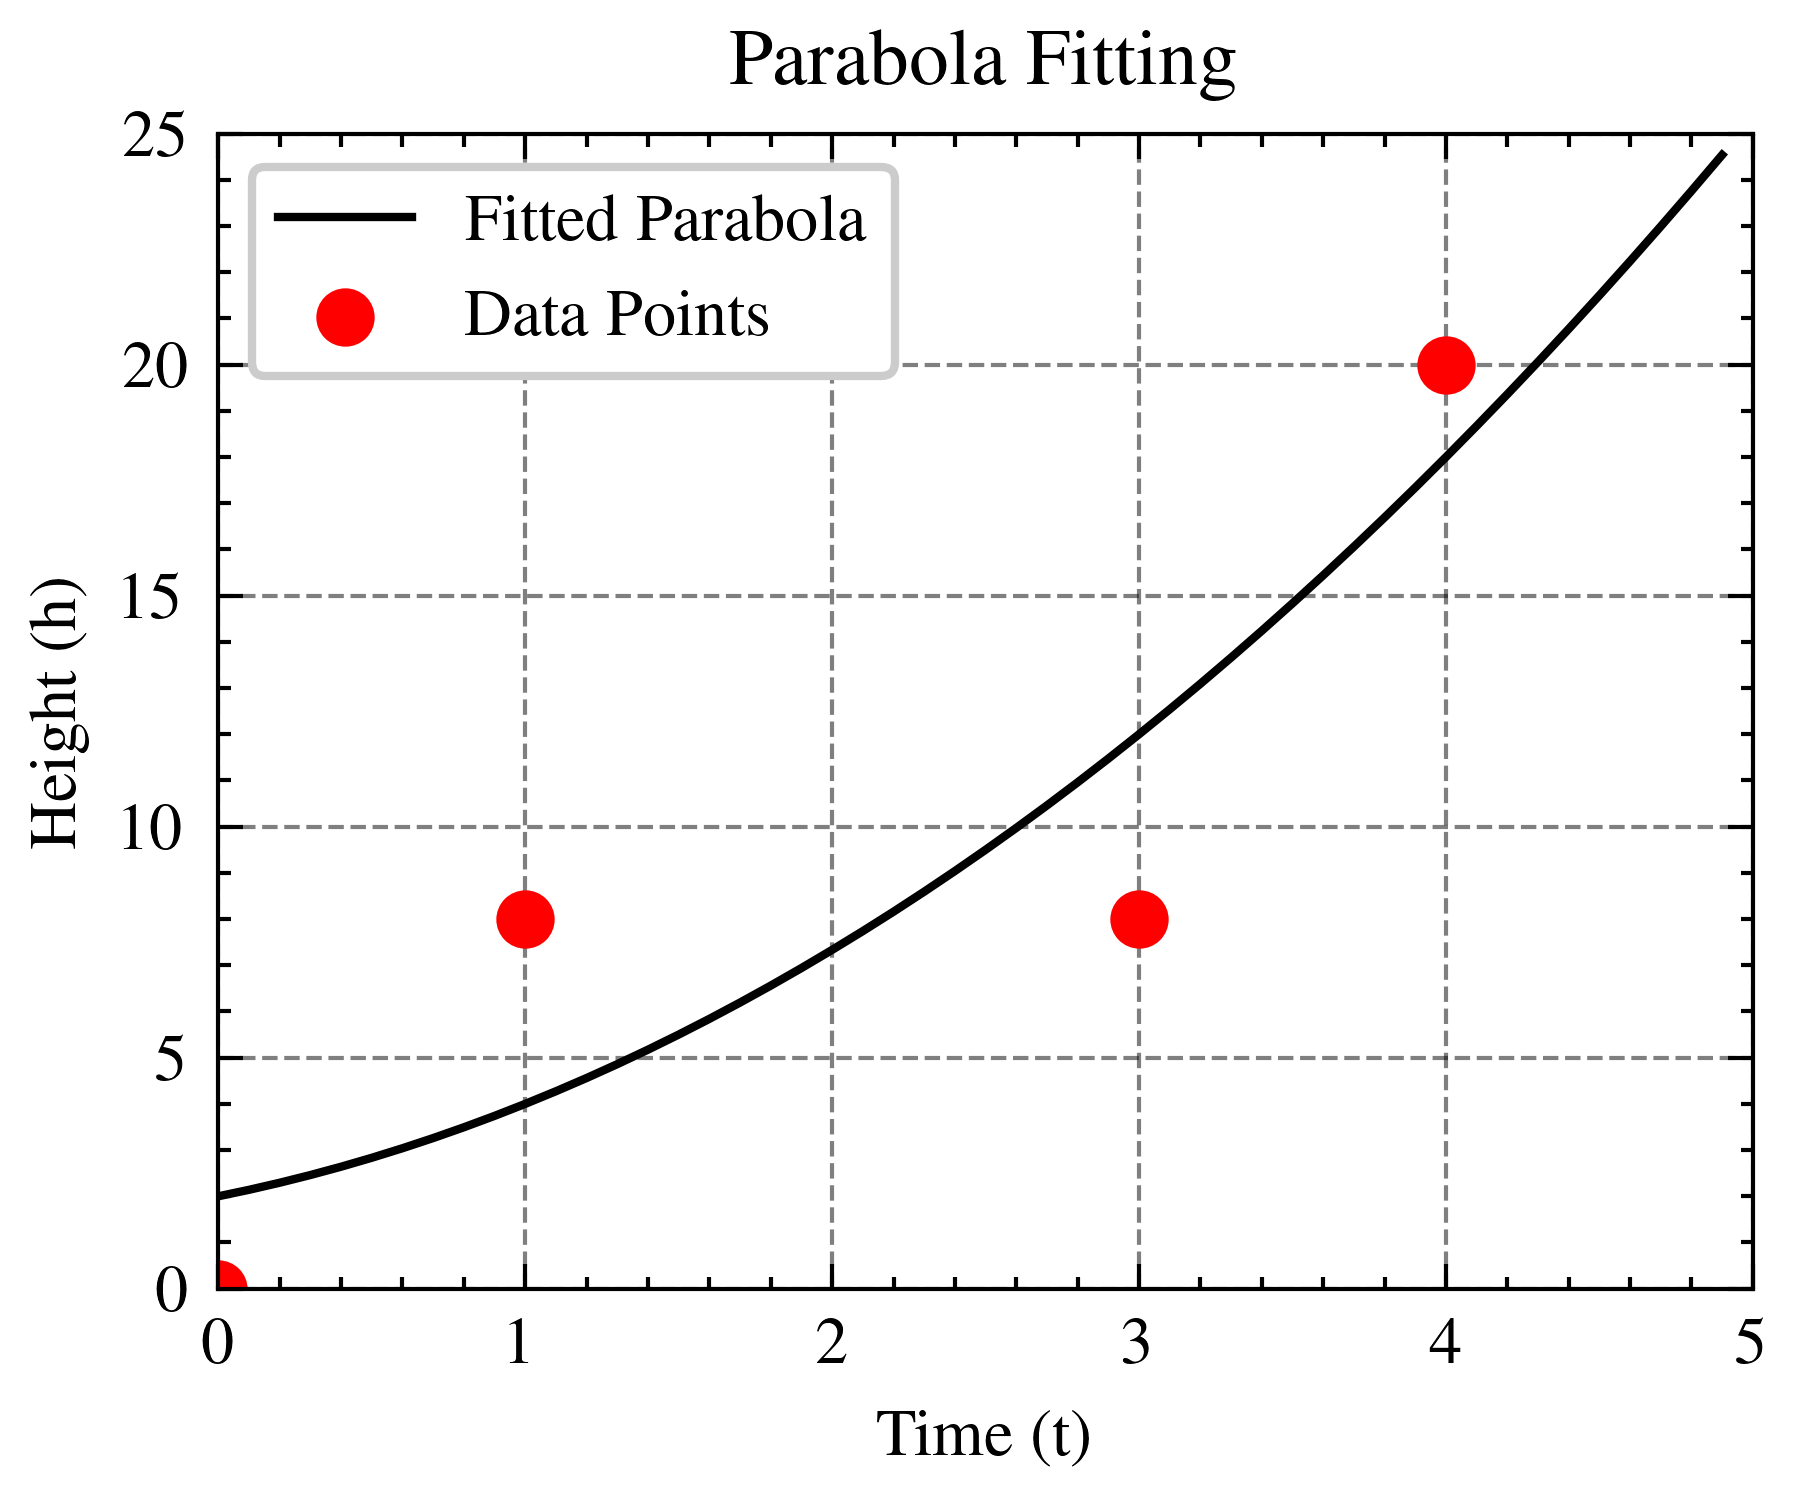

In [3]:
# Define the matrix A and vector b
A = np.array(
    [
        [1, 0, 0**2],
        [1, 1, 1**2],
        [1, 3, 3**2],
        [1, 4, 4**2],
    ]
)
b = np.array([0, 8, 8, 20])
# Solve for x using the least squares method
x = np.linalg.inv(A.T @ A) @ A.T @ b
# Extract coefficients
c, d, e = x[0], x[1], x[2]

# Define the range for plotting the parabola
x2 = np.arange(0, 5, 0.1)
y = c + d * x2 + e * x2**2
# Original four data points
x3 = np.array([0, 1, 3, 4])
y3 = np.array([0, 8, 8, 20])
# Plot the parabola
plt.plot(x2, y, label="Fitted Parabola")
plt.scatter(x3, y3, color="red", label="Data Points")
plt.xlabel("Time (t)")
plt.ylabel("Height (h)")
plt.legend()
plt.title("Parabola Fitting")
plt.grid(True)
plt.xlim(0, 5)  # Set x-axis range from 0
plt.ylim(0, 25)  # Set y-axis range from 0
plt.show()

### Problem 6

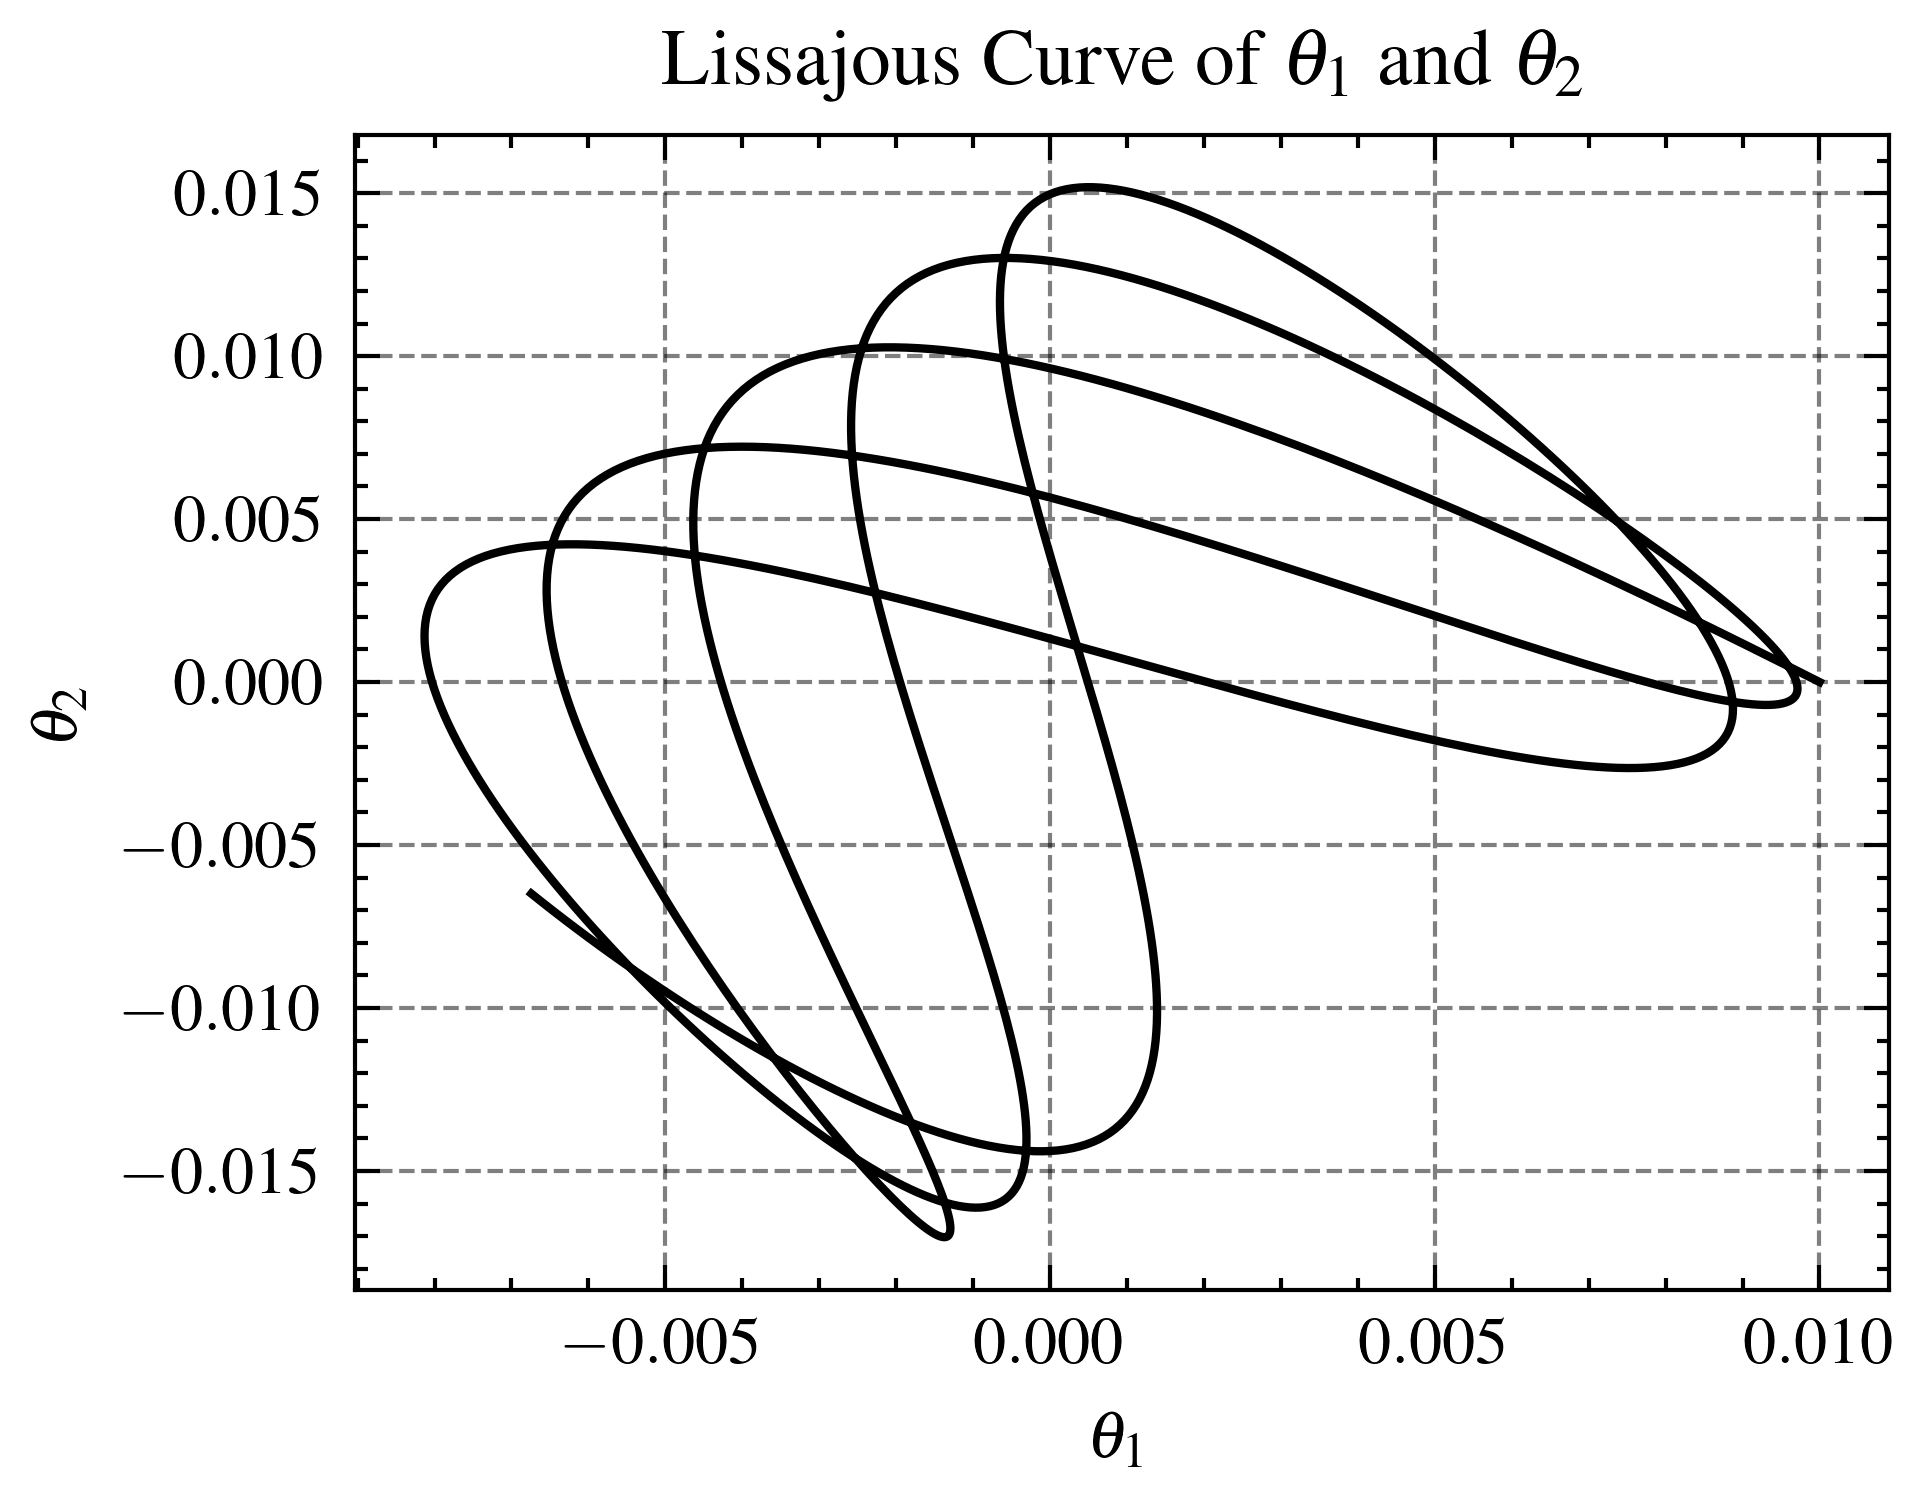

In [4]:
# define the parameters
g = 9.81
m1 = 1.0
m2 = 0.5
l1 = 1.0
l2 = 1.0


# define the eqution
def equations(t, y):
    theta1, theta2, omega1, omega2 = y
    A = np.array(
        [
            [-(2 * m1 + m2) * g / l1, 2 * m2 * g / l1],
            [2 * g * (m1 + m2) / l2, -2 * g * (m1 + m2) / l2],
        ]
    )
    dtheta = np.array([omega1, omega2])
    domega = A @ np.array([theta1, theta2])
    return [dtheta[0], dtheta[1], domega[0], domega[1]]


# we assume the initial conditions as following
theta1_0 = 0.01
theta2_0 = 0.0
omega1_0 = 0.0
omega2_0 = 0.0
y0 = [theta1_0, theta2_0, omega1_0, omega2_0]

# time
t_span = (0, 5)
t_eval = np.linspace(0, 5, 1000)

# solve
sol = solve_ivp(equations, t_span, y0, t_eval=t_eval)

# Plot the Lissajous curve
plt.plot(sol.y[0], sol.y[1])  #  with the small angle approximation
plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.title("Lissajous Curve of $\\theta_1$ and $\\theta_2$")
plt.grid(True)
plt.show()